# Cancer Risk Prediction

This notebook trains a classification model and explains how well it performs. Exploratory analysis is in `eda.ipynb`.

The target is **not a medical diagnosis**. It is a three-class risk label:

- **Low**
- **Medium**
- **High**

A FastAPI service in `app.py` serves the trained model after you run `train.py` (or the last cell in this notebook).

## 1. Setup and data loading

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

LEVEL_ORDER = ["Low", "Medium", "High"]
LEVEL_COLORS = {"Low": "#4C9F70", "Medium": "#E0A100", "High": "#C0392B"}
ID_COLUMNS = ["index", "Patient Id"]
TARGET = "Level"

df = pd.read_csv("cancer data.csv")
df.head()

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


## 2. Dataset overview

Each row is one patient. Most columns are ordinal scores for lifestyle, environmental exposure, medical history, and symptoms. `Level` is the cancer-risk class we want to predict.

We drop `index` and `Patient Id` because they identify the person and do not describe risk.

In [2]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Unique patients: {df['Patient Id'].nunique()}")
print("\nClass balance:")
print(df[TARGET].value_counts().reindex(LEVEL_ORDER))
print("\nColumn types:")
print(df.dtypes)

Rows: 1000, Columns: 26
Missing values: 0
Duplicate rows: 0
Unique patients: 1000

Class balance:
Level
Low       303
Medium    332
High      365
Name: count, dtype: int64

Column types:
index                       int64
Patient Id                    str
Age                         int64
Gender                      int64
Air Pollution               int64
Alcohol use                 int64
Dust Allergy                int64
OccuPational Hazards        int64
Genetic Risk                int64
chronic Lung Disease        int64
Balanced Diet               int64
Obesity                     int64
Smoking                     int64
Passive Smoker              int64
Chest Pain                  int64
Coughing of Blood           int64
Fatigue                     int64
Weight Loss                 int64
Shortness of Breath         int64
Wheezing                    int64
Swallowing Difficulty       int64
Clubbing of Finger Nails    int64
Frequent Cold               int64
Dry Cough                   int

In [3]:
feature_cols = [c for c in df.columns if c not in ID_COLUMNS + [TARGET]]
X = df[feature_cols].copy()
y = df[TARGET].astype(str)

print("Features used for modeling:")
print(feature_cols)
print(f"Unique feature profiles: {X.drop_duplicates().shape[0]}")
df[feature_cols].describe().T

Features used for modeling:
['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring']
Unique feature profiles: 152


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,37.174,12.005493,14.0,27.75,36.0,45.0,73.0
Gender,1000.0,1.402,0.490547,1.0,1.00,1.0,2.0,2.0
Air Pollution,1000.0,3.840,2.030400,1.0,2.00,3.0,6.0,8.0
Alcohol use,1000.0,4.563,2.620477,1.0,2.00,5.0,7.0,8.0
Dust Allergy,1000.0,5.165,1.980833,1.0,4.00,6.0,7.0,8.0
OccuPational Hazards,1000.0,4.840,2.107805,1.0,3.00,5.0,7.0,8.0
Genetic Risk,1000.0,4.580,2.126999,1.0,2.00,5.0,7.0,7.0
chronic Lung Disease,1000.0,4.380,1.848518,1.0,3.00,4.0,6.0,7.0
Balanced Diet,1000.0,4.491,2.135528,1.0,2.00,4.0,7.0,7.0
Obesity,1000.0,4.465,2.124921,1.0,3.00,4.0,7.0,7.0


**What this tells us**

- There are 1,000 unique patients and no missing values, so no imputation is required.
- The three risk classes are fairly balanced (High 365, Medium 332, Low 303). Accuracy is therefore a useful metric, but we still report precision, recall, and F1 so one class cannot hide errors.
- Age ranges from 14 to 73. Almost every other feature is a 1–9 style score, so they can be used as numeric features without one-hot encoding.
- There are only 152 unique feature profiles. Many patients share the same scores, and each profile has one label.

## 3. Visualizations

### 3.1 Risk-level counts

High risk is the largest group, but not by a large margin. A model that always predicted High would only be about 36.5% accurate, so any much higher score means the features carry real signal.

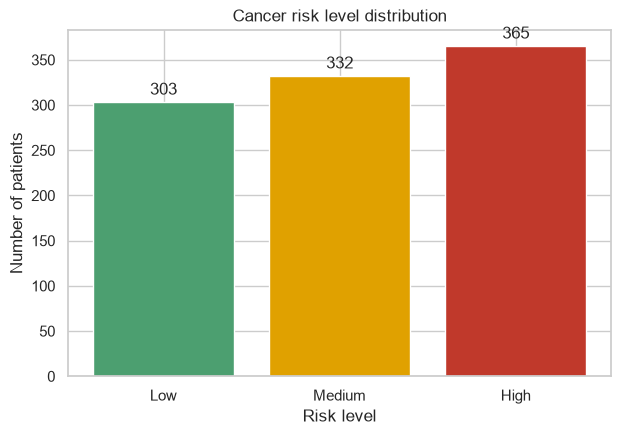

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
counts = df[TARGET].value_counts().reindex(LEVEL_ORDER)
bars = ax.bar(counts.index, counts.values, color=[LEVEL_COLORS[k] for k in counts.index])
ax.bar_label(bars, padding=3)
ax.set_title("Cancer risk level distribution")
ax.set_xlabel("Risk level")
ax.set_ylabel("Number of patients")
plt.show()

### 3.2 Age and gender

Age overlaps a lot across the three classes, so age alone is a weak predictor. Gender 1 is more common in the data than gender 2; the original file encodes gender as 1/2 rather than male/female labels.

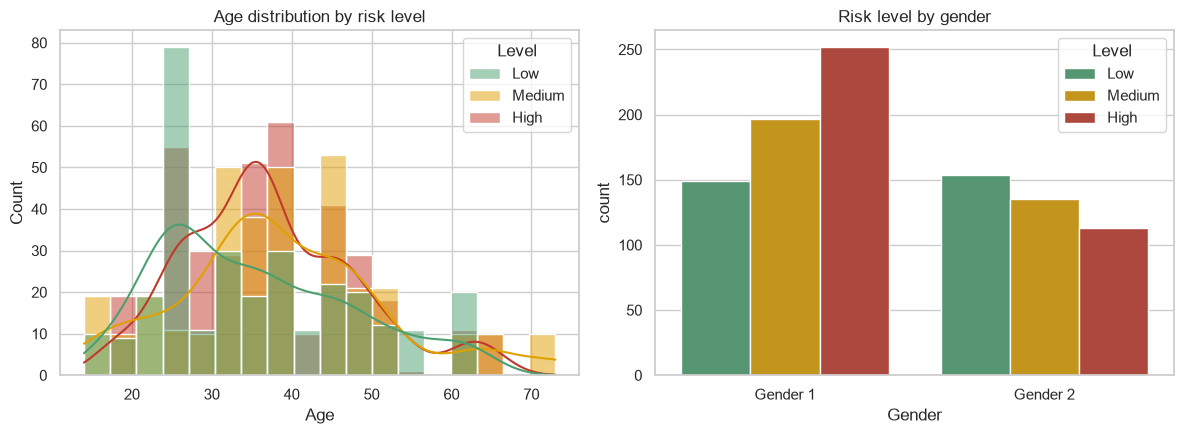

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(
    data=df, x="Age", hue=TARGET, hue_order=LEVEL_ORDER,
    palette=LEVEL_COLORS, ax=axes[0], kde=True
)
axes[0].set_title("Age distribution by risk level")

gender_df = df.assign(GenderLabel=df["Gender"].map({1: "Gender 1", 2: "Gender 2"}))
sns.countplot(
    data=gender_df, x="GenderLabel", hue=TARGET,
    hue_order=LEVEL_ORDER, palette=LEVEL_COLORS, ax=axes[1]
)
axes[1].set_title("Risk level by gender")
axes[1].set_xlabel("Gender")
plt.tight_layout()
plt.show()

### 3.3 How risk factors change with the target

These boxplots are the most useful EDA view. If a feature's median rises from Low to High, the model can use that gradient. Smoking, obesity, genetic risk, alcohol use, occupational hazards, and several respiratory symptoms show that pattern.

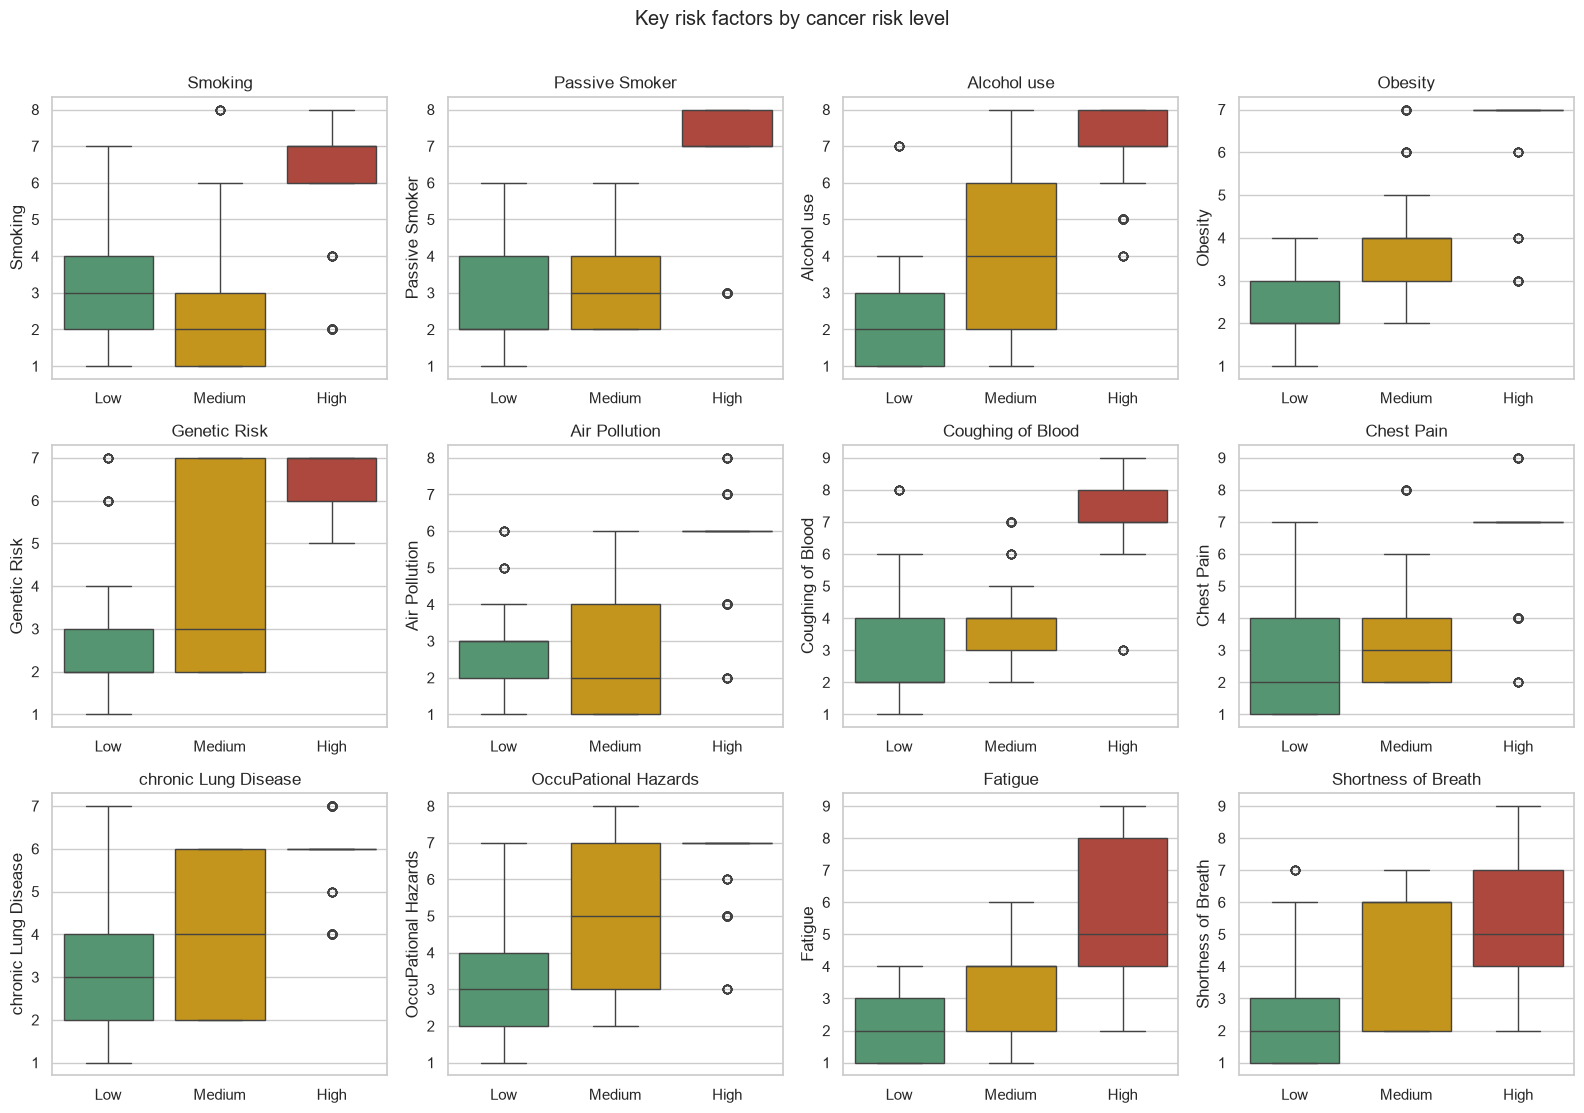

In [6]:
key_features = [
    "Smoking", "Passive Smoker", "Alcohol use", "Obesity",
    "Genetic Risk", "Air Pollution", "Coughing of Blood", "Chest Pain",
    "chronic Lung Disease", "OccuPational Hazards", "Fatigue", "Shortness of Breath",
]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, col in zip(axes.ravel(), key_features):
    sns.boxplot(
        data=df, x=TARGET, y=col, order=LEVEL_ORDER,
        hue=TARGET, hue_order=LEVEL_ORDER, palette=LEVEL_COLORS,
        ax=ax, legend=False,
    )
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Key risk factors by cancer risk level", y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Feature correlations

Several lifestyle and exposure scores move together (for example smoking, alcohol use, occupational hazards, and genetic risk). That multicollinearity is why a linear model can be less stable than a tree model. Random Forest can still use correlated features without assuming independence.

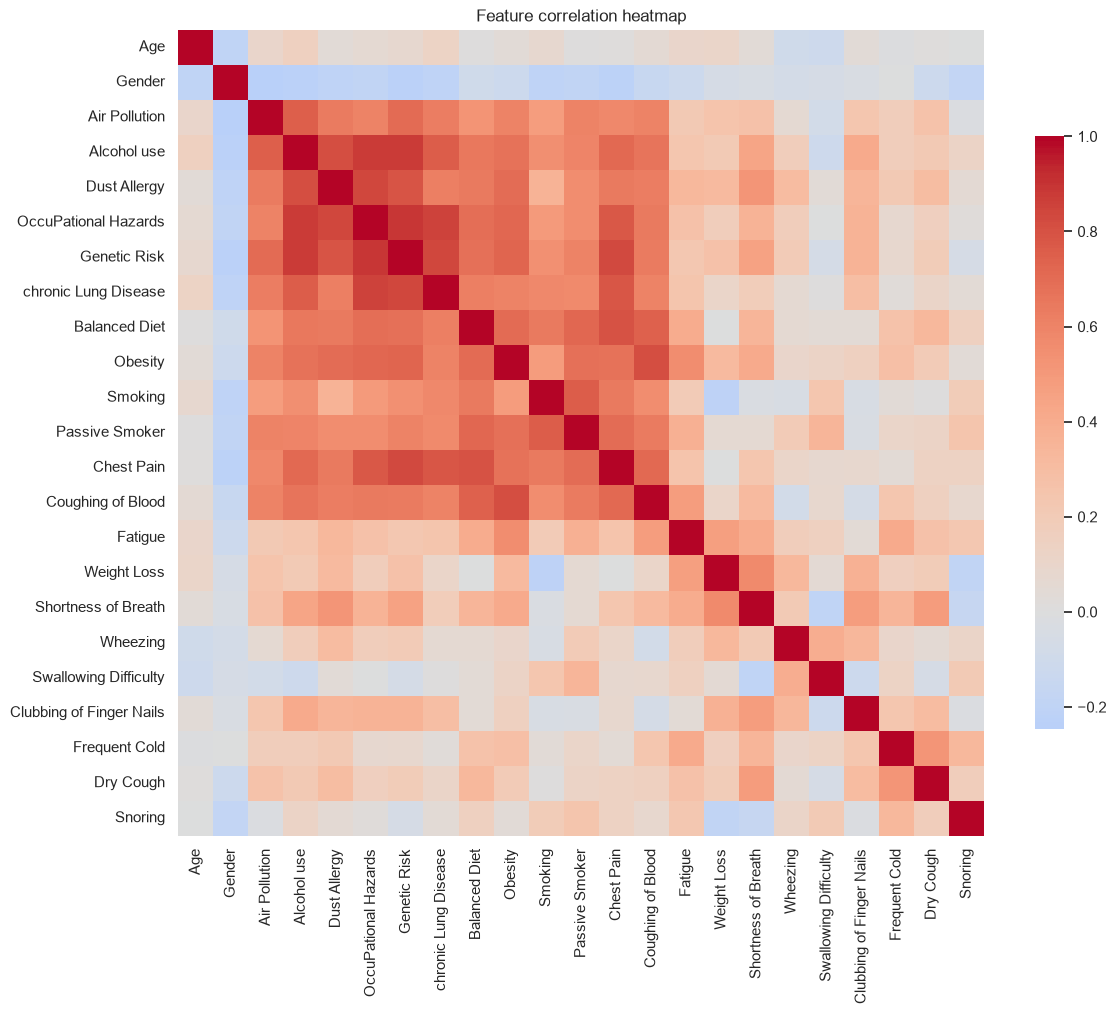

In [7]:
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    df[feature_cols].corr(numeric_only=True),
    cmap="coolwarm", center=0, ax=ax, square=True,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Feature correlation heatmap")
plt.show()

## 4. Train a prediction model

This is a **multiclass classification** problem, not regression. Treating Low/Medium/High as evenly spaced numbers hides class-specific mistakes, so we use classification metrics instead.

We compare two models:

1. **Logistic regression** — a simple linear baseline after scaling.
2. **Random forest** — an ensemble of decision trees that captures non-linear interactions and gives feature importances.

The 80/20 split is stratified so each class keeps the same share in train and test.

In [8]:
encoder = LabelEncoder()
encoder.fit(LEVEL_ORDER)
encoder.classes_ = np.array(LEVEL_ORDER)
y_encoded = np.array([LEVEL_ORDER.index(label) for label in y])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))

Train size: 800 Test size: 200
Train class counts: [242 266 292]
Test class counts: [61 66 73]


In [9]:
models = {
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ]),
    "random_forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
        )),
    ]),
}

results = {}
fitted = {}
for name, pipe in models.items():
    cv = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1_macro")
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results[name] = {
        "cv_f1_mean": cv.mean(),
        "cv_f1_std": cv.std(),
        "test_accuracy": accuracy_score(y_test, pred),
        "test_precision_macro": precision_score(y_test, pred, average="macro"),
        "test_recall_macro": recall_score(y_test, pred, average="macro"),
        "test_f1_macro": f1_score(y_test, pred, average="macro"),
    }
    fitted[name] = (pipe, pred)

pd.DataFrame(results).T.round(4)

,cv_f1_mean,cv_f1_std,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
logistic_regression,1.0,0.0,1.0,1.0,1.0,1.0
random_forest,1.0,0.0,1.0,1.0,1.0,1.0


**Why these metrics**

- **Accuracy**: overall share of correct predictions.
- **Precision**: of the patients predicted as a class, how many truly belong to it. High precision for High risk means fewer false alarms.
- **Recall**: of the patients who truly belong to a class, how many we found. High recall for High risk means fewer missed high-risk patients.
- **Macro F1**: the harmonic mean of precision and recall, averaged equally across Low, Medium, and High. This is the score we use to pick the better model.
- **5-fold CV F1**: estimates stability on the training data before looking at the held-out test set.

**Why both models can score 100%**

The file has 1,000 rows but only 152 unique feature combinations. Every repeated profile has the same `Level`. The label is a deterministic function of the scores, so a tree or a linear separator can recover the mapping. That is useful for a demo API. It is not evidence the model would diagnose new hospital patients at the same accuracy.

In [10]:
best_name = max(
    results,
    key=lambda k: (results[k]["test_f1_macro"], 1 if k == "random_forest" else 0),
)
best_pipeline, y_pred = fitted[best_name]
print(f"Selected model: {best_name}")
print(f"Test accuracy: {results[best_name]['test_accuracy']:.4f}")
print(f"Test macro F1: {results[best_name]['test_f1_macro']:.4f}")
print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=LEVEL_ORDER))

Selected model: random_forest
Test accuracy: 1.0000
Test macro F1: 1.0000

Per-class report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66
        High       1.00      1.00      1.00        73

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 5. Evaluation plots

The confusion matrix shows *which* classes get mixed up. Off-diagonal cells are errors. A clinically costly error is predicting Low when the true label is High.

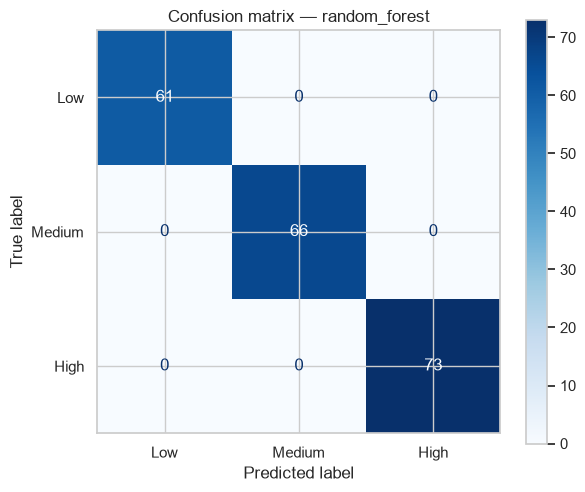

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=LEVEL_ORDER, cmap="Blues", ax=ax
)
ax.set_title(f"Confusion matrix — {best_name}")
plt.show()

### Feature importance

Random Forest importance is the average reduction in impurity when a feature is used to split. It is not a causal medical ranking, but it does show which inputs the model relied on most. Symptom and exposure scores typically dominate age and gender.

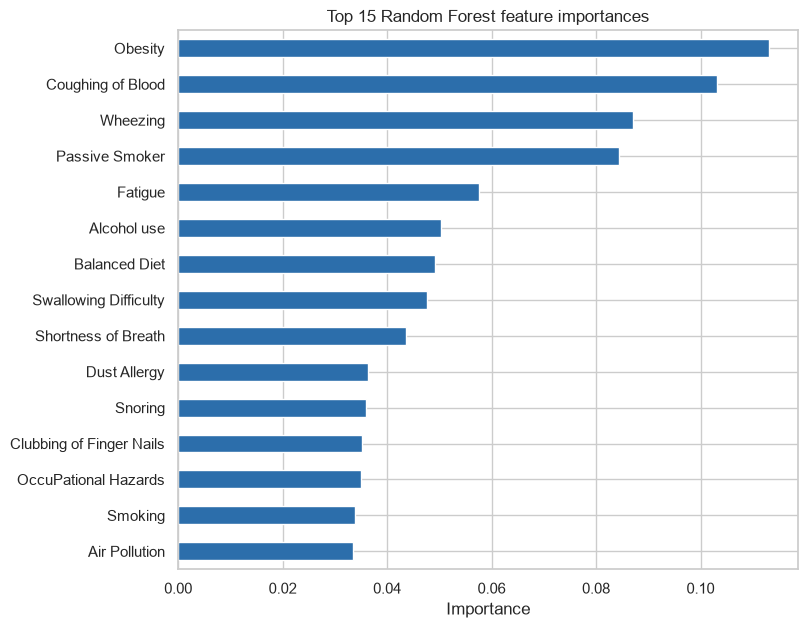

Obesity                  0.113044
Coughing of Blood        0.103185
Wheezing                 0.087000
Passive Smoker           0.084477
Fatigue                  0.057639
Alcohol use              0.050336
Balanced Diet            0.049080
Swallowing Difficulty    0.047552
Shortness of Breath      0.043625
Dust Allergy             0.036355
dtype: float64


In [12]:
forest = fitted["random_forest"][0].named_steps["model"]
importances = pd.Series(forest.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
importances.tail(15).plot(kind="barh", ax=ax, color="#2C6EAB")
ax.set_title("Top 15 Random Forest feature importances")
ax.set_xlabel("Importance")
plt.show()

print(importances.sort_values(ascending=False).head(10))

### Example prediction

The API uses the same pipeline. A single patient record is passed as a one-row table with the original column names.

In [13]:
example = X_test.iloc[[0]]
true_label = LEVEL_ORDER[y_test[0]]
pred_label = LEVEL_ORDER[int(best_pipeline.predict(example)[0])]
proba = best_pipeline.predict_proba(example)[0]

print("True risk:", true_label)
print("Predicted risk:", pred_label)
print("Class probabilities:")
for name, p in zip(LEVEL_ORDER, proba):
    print(f"  {name:6s} {p:.3f}")
example

True risk: Medium
Predicted risk: Medium
Class probabilities:
  Low    0.000
  Medium 1.000
  High   0.000


,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring
404,62,1,6,8,7,7,7,6,2,4,...,3,2,7,6,5,1,9,3,4,2


## 6. Save the model for the API

The artifact stored under `models/` is exactly what `app.py` loads. After this cell you can start the API with:

```bash
uvicorn app:app --reload
```

Then open `http://127.0.0.1:8000/docs` to try `POST /predict`.

In [14]:
Path("models").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

metrics = {
    "best_model": best_name,
    "comparison": results,
    "test": {
        "accuracy": results[best_name]["test_accuracy"],
        "precision_macro": results[best_name]["test_precision_macro"],
        "recall_macro": results[best_name]["test_recall_macro"],
        "f1_macro": results[best_name]["test_f1_macro"],
        "classification_report": classification_report(
            y_test, y_pred, target_names=LEVEL_ORDER, output_dict=True
        ),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
    },
}

artifact = {
    "pipeline": best_pipeline,
    "label_encoder": encoder,
    "feature_names": feature_cols,
    "class_names": LEVEL_ORDER,
    "model_name": best_name,
    "metrics": metrics,
}
joblib.dump(artifact, "models/cancer_risk_model.joblib")
Path("models/metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print("Saved models/cancer_risk_model.joblib")

Saved models/cancer_risk_model.joblib


## 7. How to call the API

Send the same feature names as in the CSV:

```bash
curl -X POST http://127.0.0.1:8000/predict ^
  -H "Content-Type: application/json" ^
  -d "{\"Age\": 35, \"Gender\": 1, \"Air Pollution\": 4, \"Alcohol use\": 5, \"Dust Allergy\": 6, \"OccuPational Hazards\": 5, \"Genetic Risk\": 5, \"chronic Lung Disease\": 4, \"Balanced Diet\": 6, \"Obesity\": 7, \"Smoking\": 2, \"Passive Smoker\": 3, \"Chest Pain\": 4, \"Coughing of Blood\": 8, \"Fatigue\": 8, \"Weight Loss\": 7, \"Shortness of Breath\": 9, \"Wheezing\": 2, \"Swallowing Difficulty\": 1, \"Clubbing of Finger Nails\": 4, \"Frequent Cold\": 6, \"Dry Cough\": 7, \"Snoring\": 2}"
```

The response contains the predicted risk (`Low`, `Medium`, or `High`) and class probabilities.

**Limitations**

- This dataset is a public educational table of risk scores, not a hospital EHR extract.
- Near-perfect test scores happen because many patients share the same score profile.
- Do not use the API as a substitute for clinical judgment.